<a href="https://colab.research.google.com/github/Givi-Modebadze/ML_Final_Project/blob/main/experiments/LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'ML_Final_Project/walmart-recruiting-store-sales-forecasting'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/ML_Final_Project/walmart-recruiting-store-sales-forecasting


# Merge data

In [34]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

def merger(df, stores, features):
    df = df.merge(stores, how='left', on='Store')
    df = df.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
    return df

df = merger(df, stores, features)
test = merger(test, stores, features)

df.sort_values('Date', inplace=True)
test.sort_values('Date', inplace=True)

y = df['Weekly_Sales']
X = df.drop(columns=['Weekly_Sales'])
dates = df['Date']

# Preprocessor

In [35]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class Preprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.type_encoder = None

    def fit(self, X: pd.DataFrame, y=None):
        if 'Type' in X.columns:
            self.type_encoder = X['Type'].astype('category').cat.categories
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()

        X['Date'] = pd.to_datetime(X['Date'])
        X['Year'] = X['Date'].dt.year
        X['Month'] = X['Date'].dt.month
        X['Day'] = X['Date'].dt.day

        if self.type_encoder is not None:
            X['Type'] = pd.Categorical(X['Type'], categories=self.type_encoder)
            X['Type'] = X['Type'].cat.codes

        if 'IsHoliday' in X.columns:
            X['IsHoliday'] = X['IsHoliday'].astype(int)

        return X


In [36]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop=None):
        self.columns_to_drop = columns_to_drop or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=self.columns_to_drop, errors='ignore')

In [37]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.holidays = {
            'IsSuperBowl': ['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'],
            'IsLaborDay': ['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'],
            'IsThanksgiving': ['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'],
            'IsChristmas': ['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']
        }

    def fit(self, X, y=None):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'])
        X['Weekly_Sales'] = y.values
        X['Year'] = X['Date'].dt.year
        X['Week'] = X['Date'].dt.isocalendar().week.astype(int)
        self.full_data_ = X[['Store', 'Dept', 'Date', 'Year', 'Week', 'Weekly_Sales']].copy()
        return self

    def transform(self, X):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'])
        X['Year'] = X['Date'].dt.year
        X['Month'] = X['Date'].dt.month
        X['Week'] = X['Date'].dt.isocalendar().week.astype(int)
        X['Day'] = X['Date'].dt.day
        X['DayOfWeek'] = X['Date'].dt.dayofweek

        for k in range(1, 3):
            X[f'Week_sin_{k}'] = np.sin(2 * np.pi * k * X['Week'] / 52)
            X[f'Week_cos_{k}'] = np.cos(2 * np.pi * k * X['Week'] / 52)

        X['DayOfYear'] = X['Date'].dt.dayofyear
        for k in range(1, 3):
            X[f'DayOfYear_sin_{k}'] = np.sin(2 * np.pi * k * X['DayOfYear'] / 365)
            X[f'DayOfYear_cos_{k}'] = np.cos(2 * np.pi * k * X['DayOfYear'] / 365)


        for holiday_name, date_list in self.holidays.items():
            holiday_dates = pd.to_datetime(date_list)

            X[holiday_name] = X['Date'].isin(holiday_dates).astype(int)
            week_before = holiday_dates - pd.Timedelta(weeks=1)
            week_after = holiday_dates + pd.Timedelta(weeks=1)

            X[f'{holiday_name}Before'] = X['Date'].isin(week_before).astype(int)
            X[f'{holiday_name}After'] = X['Date'].isin(week_after).astype(int)

        base = self.full_data_.copy()
        last_year = base.copy()
        last_year['Year'] += 1
        last_year = last_year.rename(columns={'Weekly_Sales': 'Sales_LastYear'})

        df = X.merge(
            last_year[['Store', 'Dept', 'Year', 'Week', 'Sales_LastYear']],
            on=['Store', 'Dept', 'Year', 'Week'],
            how='left'
        )

        two_years_ago = base.copy()
        two_years_ago['Year'] += 2
        two_years_ago = two_years_ago.rename(columns={'Weekly_Sales': 'Sales_TwoYearsAgo'})

        df = df.merge(
            two_years_ago[['Store', 'Dept', 'Year', 'Week', 'Sales_TwoYearsAgo']],
            on=['Store', 'Dept', 'Year', 'Week'],
            how='left'
        )

        df['PrevYearSales'] = df['Sales_LastYear'].fillna(df['Sales_TwoYearsAgo'])
        df.drop(columns=['Sales_LastYear', 'Sales_TwoYearsAgo'], inplace=True)

        return df

# cross validation

In [38]:
def weighted_mae(y_true, y_pred, is_holiday):
    weights = is_holiday * 4 + 1
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

def cross_validation(pipeline, X, y, df_with_dates):
    from matplotlib.dates import DateFormatter

    tscv = TimeSeriesSplit(n_splits=6)
    rmse_scores = []
    wmae_scores = []
    train_rmse_scores = []
    train_wmae_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        if fold < 4:
          continue

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_train, y_train)

        y_val_pred = pipeline.predict(X_val)
        y_train_pred = pipeline.predict(X_train)

        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

        val_is_holiday = df_with_dates.iloc[val_idx]['IsHoliday'].astype(int)
        train_is_holiday = df_with_dates.iloc[train_idx]['IsHoliday'].astype(int)

        val_wmae = weighted_mae(y_val, y_val_pred, val_is_holiday)
        train_wmae = weighted_mae(y_train, y_train_pred, train_is_holiday)

        print(f"\nFold {fold + 1} Scores:")
        print(f"Train RMSE: {train_rmse:.2f} | Train WMAE: {train_wmae:.2f}")
        print(f"Valid RMSE: {val_rmse:.2f} | Valid WMAE: {val_wmae:.2f}")

        rmse_scores.append(val_rmse)
        wmae_scores.append(val_wmae)
        train_rmse_scores.append(train_rmse)
        train_wmae_scores.append(train_wmae)

        df_all = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates['Date']),
            'y': y.values
        })
        df_all = df_all.groupby('Date').sum().reset_index().sort_values('Date')

        df_val = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates.iloc[val_idx]['Date']),
            'Actual': y_val.values,
            'Predicted': y_val_pred
        }).groupby('Date').sum().reset_index().sort_values('Date')

        df_train = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates.iloc[train_idx]['Date']),
            'Actual': y_train.values,
            'Predicted': y_train_pred
        }).groupby('Date').sum().reset_index().sort_values('Date')

        plt.figure(figsize=(12, 4))

        plt.plot(df_all['Date'], df_all['y'], color='gray', label='Train Actuals', linewidth=1.5, alpha=0.4)

        plt.plot(df_train['Date'], df_train['Predicted'], color='green', label='Train Predicted', linewidth=1.5, alpha=0.8)

        plt.plot(df_val['Date'], df_val['Actual'], color='blue', label='Val Actuals', linewidth=2)

        plt.plot(df_val['Date'], df_val['Predicted'], color='orange', label='Val Predicted', linewidth=2)

        plt.title(f'Fold {fold + 1} - Weekly Sales Over Time', fontsize=14)
        plt.xlabel("Date")
        plt.ylabel("Weekly Sales")
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(f"\nMean Train RMSE: {np.mean(train_rmse_scores):.2f}")
    print(f"Mean Train WMAE: {np.mean(train_wmae_scores):.2f}")
    print(f"Mean Valid RMSE: {np.mean(rmse_scores):.2f}")
    print(f"Mean Valid WMAE: {np.mean(wmae_scores):.2f}")


# Pipeline


Fold 5 Scores:
Train RMSE: 3407.13 | Train WMAE: 1982.90
Valid RMSE: 3961.18 | Valid WMAE: 1876.70


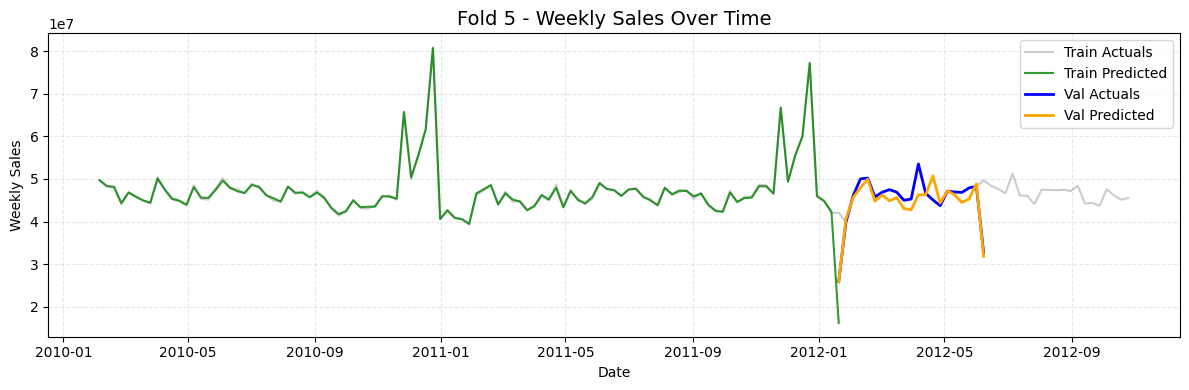


Fold 6 Scores:
Train RMSE: 3380.98 | Train WMAE: 1960.23
Valid RMSE: 3486.09 | Valid WMAE: 1710.17


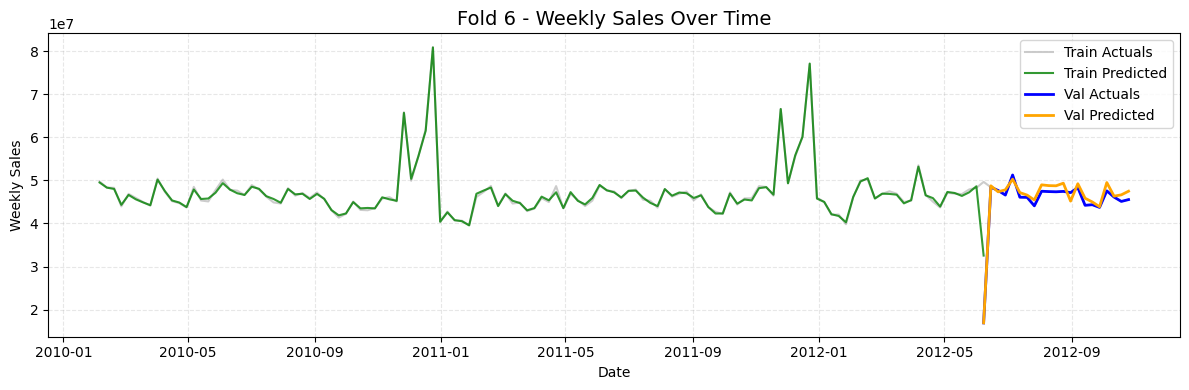


Mean Train RMSE: 3394.06
Mean Train WMAE: 1971.56
Mean Valid RMSE: 3723.63
Mean Valid WMAE: 1793.44


In [41]:
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor

params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 150,
    'learning_rate': 0.15,
    'feature_fraction': 1,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
    'reg_alpha': 0.2,
    'reg_lambda': 0.2
}

preprocessor = Preprocessor()
feature_selection = FeatureSelector(columns_to_drop=['IsHoliday','Date'])
feature_engineer = FeatureEngineer()
model = LGBMRegressor(**params)

pipeline = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocessor', preprocessor),
    ('feature selection', feature_selection),
    ('model', model)
])


cross_validation(pipeline, X, y, df)

In [ ]:
pipeline.fit(X, y)

Pipeline(steps=[('feature_engineer', FeatureEngineer()),
                ('preprocessor', Preprocessor()),
                ('feature selection',
                 FeatureSelector(columns_to_drop=['IsHoliday', 'Date'])),
                ('model',
                 LGBMRegressor(bagging_fraction=0.8, bagging_freq=5,
                               feature_fraction=1, metric='mae', num_leaves=150,
                               objective='regression', random_state=42,
                               reg_alpha=0.05, reg_lambda=0.05, verbose=-1))])

In [ ]:
!pip install dagshub
!pip install "mlflow<3"

import mlflow
import dagshub

dagshub.init(repo_owner='gbend22', repo_name='ML_Final_Project', mlflow=True)

experiment = "Final Project LightGBM"
mlflow.set_experiment(experiment)

Initialized MLflow to track repo "gbend22/ML_Final_Project"

Repository gbend22/ML_Final_Project initialized!

2025/07/17 08:22:20 INFO mlflow.tracking.fluent: Experiment with name 'Final Project LightGBM' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/73e046af08a64190b883cb13679259d9', creation_time=1752740540494, experiment_id='3', last_update_time=1752740540494, lifecycle_stage='active', name='Final Project LightGBM', tags={}>

In [ ]:
with mlflow.start_run(run_name="higher_reg_and_lr") as run:
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="LightGBM_pipeline_model",
        registered_model_name="LightGBMPipelineModel"
    )

    mlflow.log_params({
        'num_leaves': 150,
        'learning_rate': 0.15,
        'feature_fraction': 1,
        "random_state": 42
    })

    mlflow.log_metrics({
        "Mean Train RMSE" : 1793.44,
        "Mean Train WMAE" : 2113.45,
        "Mean Valid RMSE" : 3723.63,
        "Mean Valid WMAE" : 1971.56,
    })

2025/07/17 08:51:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'LightGBMPipelineModel' already exists. Creating a new version of this model...
2025/07/17 08:51:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LightGBMPipelineModel, version 6
Created version '6' of model 'LightGBMPipelineModel'.


🏃 View run higher_reg_and_lr at: https://dagshub.com/gbend22/ML_Final_Project.mlflow/#/experiments/3/runs/fab8ed986ef34ecaa7e252a9a5d75fc4
🧪 View experiment at: https://dagshub.com/gbend22/ML_Final_Project.mlflow/#/experiments/3


In [43]:
y = df['Weekly_Sales']
X = df.drop(columns=['Weekly_Sales'])

pipeline.fit(X,y)

test_pred = pipeline.predict(test)
submission = test[['Store', 'Dept', 'Date']].copy()
submission['Id'] = submission['Store'].astype(str) + '_' + submission['Dept'].astype(str) + '_' + submission['Date'].astype(str)
submission['Weekly_Sales'] = test_pred
submission = submission[['Id', 'Weekly_Sales']]
submission.to_csv("submission.csv", index=False)
